# Analysis of Scooter Rental Service GoFast

We have data about some users from several cities, as well as their rides. We need to analyze this data and verify some hypotheses that might help the business grow.

To make trips around the city, users of the GoFast service use a mobile application. The service can be used:

**Without a subscription**

- No subscription fee;
- Cost per minute of a ride — 8 rubles;
- Start fee (trip initiation) — 50 rubles.

**With Ultra subscription**

- Subscription fee — 199 rubles per month;
- Cost per minute of a ride — 6 rubles;
- No start fee.

**Research Objectives**

- Study user information and behavior, optimize business processes, identify potential areas for improvement and business growth.

**Research Steps**

- Data loading and preprocessing;
- Exploratory data analysis;
- Data merging;
- Revenue calculation based on subscription and non-subscription payment terms;
- Testing hypotheses: differences in trip duration between subscribers and non-subscribers, average trip distances for subscribers, comparing monthly revenue from different user categories, and evaluating the impact of a technical update on support ticket volume;
- Conclusion.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
import numpy as np

#### Data Loading

In [2]:
# Reading CSV files
df_users = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')

In [3]:
# Displaying rows
df_users.head(10)

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra


In [4]:
# Checking city names
df_users['city'].unique()

array(['Тюмень', 'Омск', 'Москва', 'Ростов-на-Дону', 'Краснодар',
       'Пятигорск', 'Екатеринбург', 'Сочи'], dtype=object)

In [5]:
# Create a dictionary of translations
city_translations = {
    'Тюмень': 'Tyumen',
    'Омск': 'Omsk',
    'Москва': 'Moscow',
    'Ростов-на-Дону': 'Rostov-on-Don',
    'Краснодар': 'Krasnodar',
    'Сочи': 'Sochi',
    'Пятигорск': 'Pyatigorsk',
    'Екатеринбург': 'Yekaterinburg'
}

# Apply the dictionary mapping to the 'city' column
df_users['city'] = df_users['city'].map(city_translations)

# Verify the changes
df_users.head(10)


,user_id,name,age,city,subscription_type
0,1,Кира,22,Tyumen,ultra
1,2,Станислав,31,Omsk,ultra
2,3,Алексей,20,Moscow,ultra
3,4,Константин,26,Rostov-on-Don,ultra
4,5,Адель,28,Omsk,ultra
5,6,Регина,25,Krasnodar,ultra
6,7,Игорь,23,Omsk,ultra
7,8,Юрий,23,Krasnodar,ultra
8,9,Ян,21,Pyatigorsk,ultra
9,10,Валерий,18,Yekaterinburg,ultra


In [6]:
# Displaying information
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


There are no missing values. Data types correspond to their content.

In [7]:
# Counting duplicate rows
df_users.duplicated().sum()


31

Number of obvoius duplicates - 31

In [8]:
# Reading CSV files
df_riders = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
# Displaying rows
df_riders.head(10)


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
5,1,2770.890808,16.650138,2021-10-09
6,1,3039.020292,14.927879,2021-10-19
7,1,2842.118050,23.117468,2021-11-06
8,1,3412.690668,15.238072,2021-11-14
9,1,748.690645,15.041884,2021-11-22


In [9]:
# Displaying information
df_riders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


There are no missing values. Data types correspond to their content, except for the date column, which is of type object.

In [10]:
# Counting duplicate rows
df_riders.duplicated().sum()

0

There are no obvious duplicates.

In [11]:
# Reading CSV files
df_subscriptions = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')
# Displaying rows
df_subscriptions.head(10)

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [12]:
# Displaying information
df_subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


In [13]:
# Counting duplicate rows
df_subscriptions.duplicated().sum()

0

There are no obvious duplicates.

##### Conclusion:

We have 3 dataframes.

Column names follow a consistent style (snake_case); no changes are needed.

**Data Quality:** No missing values in the dataframes. Data types match the content, except for the 'date' column in df_riders, which has type object. This needs to be corrected during preprocessing.

**Duplicates:** Number of explicit duplicates - 31 in df_users.


#### Data Preprocessing


##### Convert 'date' column to datetime type


In [14]:
df_riders['date'] = pd.to_datetime(df_riders['date'], format='%Y-%m-%d')
df_riders['date']

0       2021-01-01
1       2021-01-18
2       2021-04-20
3       2021-08-11
4       2021-08-28
           ...    
18063   2021-11-04
18064   2021-11-16
18065   2021-11-18
18066   2021-11-27
18067   2021-12-29
Name: date, Length: 18068, dtype: datetime64[ns]

##### Creating a new column for month number based on the 'date' column.


In [15]:
# Checking minimum and maximum dates in the dataframe
print("Earliest date:", df_riders['date'].min())
print("Latest date:", df_riders['date'].max())


Earliest date: 2021-01-01 00:00:00
Latest date: 2021-12-30 00:00:00


Our data covers the year 2021.


In [16]:
# Adding a new column for month of publication, verifying the result
#df_riders['month_of_publication'] = df_riders['date'].dt.month
df_riders['date'] = pd.to_datetime(df_riders['date'])
df_riders['month_of_publication'] = df_riders['date'].dt.month

df_riders


,user_id,distance,duration,date,month_of_publication
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8
...,...,...,...,...,...
18063,1534,3781.098080,19.822962,2021-11-04,11
18064,1534,2840.423057,21.409799,2021-11-16,11
18065,1534,3826.185507,18.435051,2021-11-18,11
18066,1534,2902.308661,16.674362,2021-11-27,11


##### Checking minimum and maximum dates in the dataframe


##### Handling Missing Values and Duplicates


There are no missing values in the dataframes, duplicates were found in 'df_users'.


In [17]:
# Removing explicit duplicates
df_users = df_users.drop_duplicates().reset_index(drop=True)


In [18]:
# Verifying duplicates removal
df_users.duplicated().sum()


0

##### Conclusion:

Dataframes contain no missing values. All data types match their content, except for the 'date' column in df_users, which originally had type object. This was corrected to datetime.

The dataframe contains data for the year 2021 (from January 1 to December 30).

31 explicit duplicates were found in df_users and removed. No explicit duplicates were found in other dataframes.

A new dataframe was created combining data on users, rides, and subscriptions, including a monthly revenue column for each user.


#### Exploratory Data Analysis


##### Frequency of Cities


In [19]:
df_users.pivot_table(index='city', values='user_id', aggfunc='count').sort_values(by='user_id', ascending=False)

,user_id
city,
Pyatigorsk,219
Yekaterinburg,204
Rostov-on-Don,198
Krasnodar,193
Sochi,189
Omsk,183
Tyumen,180
Moscow,168


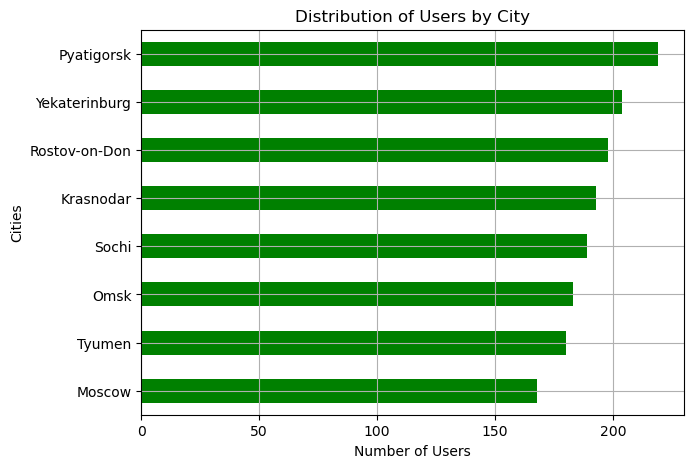

In [20]:
df_users.pivot_table(index='city', values='user_id', aggfunc='count'
                    ).sort_values(by='user_id', ascending=True
                    ).plot(kind='barh', grid=True, figsize=(7, 5), legend=False, color='green')
plt.title('Distribution of Users by City')
plt.ylabel('Cities')
plt.xlabel('Number of Users');


**Conclusion:**
The highest number of users is in Pyatigorsk (219).
High numbers are also in Yekaterinburg (204), Rostov-on-Don (198), Krasnodar (193), and Sochi (189).
Medium numbers are in Omsk (183) and Tyumen (180).
Moscow is at the bottom of the list (168). This could indicate specific data collection methods or suggest that the business focuses more on regions outside the capital.


##### Ratio of Subscribers vs. Non-subscribers


In [21]:
df_users['subscription_type'].value_counts()

subscription_type
free     835
ultra    699
Name: count, dtype: int64

In [22]:
df_users['subscription_type'].value_counts(normalize=True)

subscription_type
free     0.544329
ultra    0.455671
Name: proportion, dtype: float64

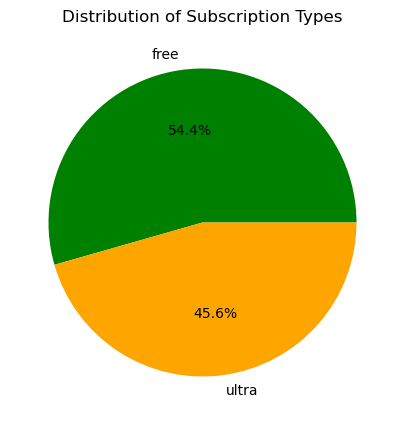

In [23]:
df_users.groupby(by='subscription_type')['subscription_type'].count(
        ).plot(kind='pie', figsize=(5, 5), autopct='%1.1f%%', colors=['green', 'orange'])
plt.ylabel("")
plt.title('Distribution of Subscription Types');


**Conclusion:**
The number of users with a free subscription is 835 (54%), and the number of users with a paid subscription (Ultra) is 699 (46%).

The free version of the service attracts more users, possibly due to the absence of financial barriers or sufficient functionality in the free version meeting most users' needs.

The paid subscription (Ultra) is also quite popular.


##### User Age Analysis


In [24]:
df_users['age'].describe().to_frame()

,age
count,1534.000000
mean,24.903520
std,4.572367
min,12.000000
25%,22.000000
50%,25.000000
75%,28.000000
max,43.000000


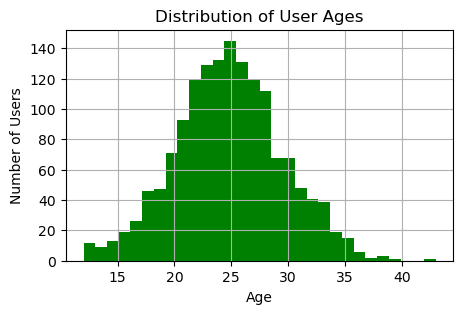

In [25]:
df_users['age'].hist(figsize=(5, 3), bins=30, color='green')
plt.title('Distribution of User Ages')
plt.xlabel('Age')
plt.ylabel('Number of Users');


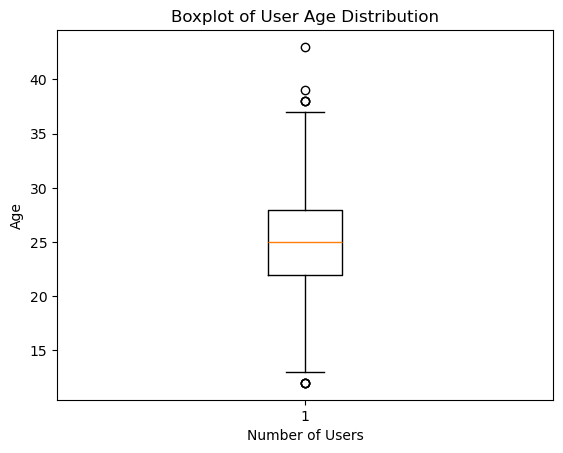

In [26]:
plt.boxplot(df_users['age'])
plt.title('Boxplot of User Age Distribution')
plt.xlabel('Number of Users')
plt.ylabel('Age')
plt.show()


**Conclusion:**
The average age of users is approximately 24.9 years.
User ages range from 12 to 43 years.
The median (50th percentile) is 25 years, which is close to the average.
The first quartile (25%) is at 22 years and the third quartile (75%) is at 28 years, indicating that most users are between 22 and 28 years old.

Based on the boxplot, the interquartile range is from 22 to 28 years, confirming that most users fall within this range.
The lower and upper "whiskers" show that user ages span roughly from 18 to 35 years.
There are two outliers — one around 15 years and another around 40 years.


##### Distance Traveled per Ride


In [27]:
df_riders['distance'].describe().round(2).to_frame()

,distance
count,18068.00
mean,3070.66
std,1116.83
min,0.86
25%,2543.23
50%,3133.61
75%,3776.22
max,7211.01


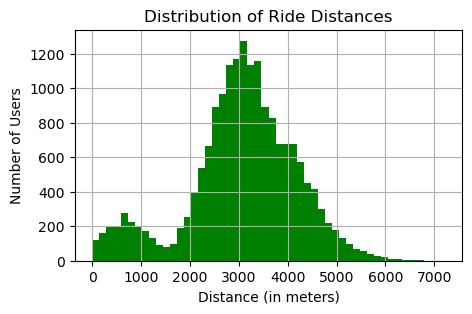

In [28]:
df_riders['distance'].hist(figsize=(5, 3), bins=50, color='green')
plt.title('Distribution of Ride Distances')
plt.xlabel('Distance (in meters)')
plt.ylabel('Number of Users');


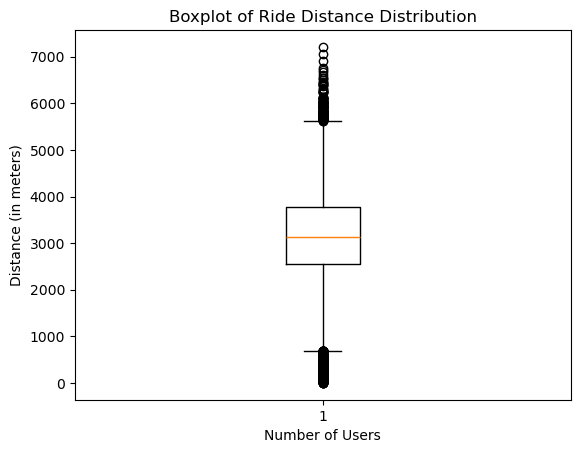

In [29]:
plt.boxplot(df_riders['distance'])
plt.title('Boxplot of Ride Distance Distribution')
plt.xlabel('Number of Users')
plt.ylabel('Distance (in meters)')
plt.show()


**Conclusion:**  
The average distance per ride is approximately 3070.66 meters.  
The standard deviation of distance is 1116.83 meters, indicating significant variation around the average. This suggests a diversity in ride types (short vs. long trips).  
The minimum recorded distance is about 0.86 meters, which could be due to registration errors or extremely short rides. The maximum distance is 7211.01 meters.

The histogram appears as two normal distributions with a small peak around 700 meters and a larger peak around 3200 meters.  
The surge in distances from 0 to 1500 meters might indicate short urban trips between close points, such as home, work, shops, or cafes, or could be due to errors.

In the boxplot, the median is around 3000 meters, with an interquartile range from 2000 to 4000 meters.  
Outliers are observed below 800 meters and above 5000 meters up to 7000 meters.

Quartile distribution: 25% of rides are shorter than 2543.23 meters, the median is 3133.61 meters, and 75% of rides are shorter than 3776.22 meters.


##### Ride Duration


In [30]:
df_riders['duration'].describe().round(2).to_frame()

,duration
count,18068.00
mean,17.81
std,6.09
min,0.50
25%,13.60
50%,17.68
75%,21.72
max,40.82


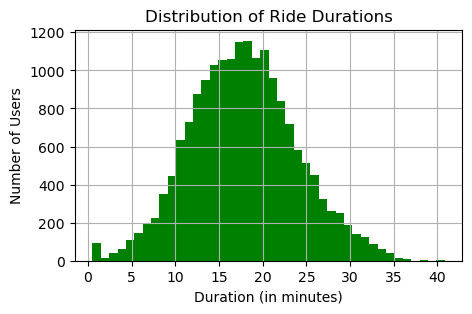

In [31]:
df_riders['duration'].hist(bins=42, figsize=(5, 3), color='green')
plt.title('Distribution of Ride Durations')
plt.xlabel('Duration (in minutes)')
plt.ylabel('Number of Users');


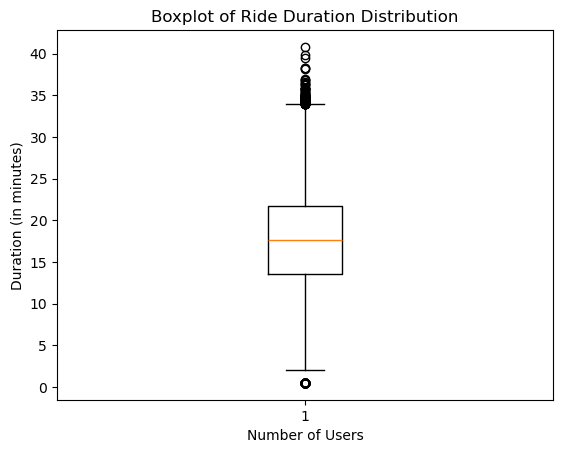

In [32]:
plt.boxplot(df_riders['duration'])
plt.title('Boxplot of Ride Duration Distribution')
plt.xlabel('Number of Users')
plt.ylabel('Duration (in minutes)')
plt.show()


In [33]:
# Check how many rides have a duration of 0.5 minutes
df_riders[df_riders['duration'] == 0.5].shape[0]


95

In [34]:
df_riders[df_riders['duration'] < 1].shape[0]

95

**Conclusion:**  
The average ride duration is approximately 17.81 minutes.  
The minimum ride duration is only 0.5 minutes. The graph shows a small peak around 0.5 minutes (95 rides), which is likely due to registration errors.  
The maximum duration is 40.82 minutes.  
Quartile distribution:  
- 25th percentile (Q1): 13.60 minutes, meaning 25% of all rides last less than 13.60 minutes.  
- Median (50th percentile): 17.68 minutes, indicating that half of the rides last less than or around this time. This value is very close to the mean, confirming a symmetrical distribution.  
- 75th percentile (Q3): 21.72 minutes, meaning 75% of rides last less than 21.72 minutes.

Based on the boxplot, the interquartile range is between 10 and 20 minutes (most rides).  
Outliers are observed between 34 and 40 minutes and one outlier around 1-2 minutes.


##### Summary

**City Frequency:**  
The highest number of users is in Pyatigorsk (219). High numbers are also seen in Yekaterinburg (204) and Rostov-on-Don (198), Krasnodar (193), and Sochi (189). Medium numbers appear in Omsk (183) and Tyumen (180). Moscow is at the bottom of the list (168).

**Subscription Ratio:**  
The number of users with a free subscription is 835 (54%), while users with a paid subscription (ultra) number 699 (46%).

**User Age:**  
User ages range from 12 to 43 years. The average age is 24.9 years, and the median is 25 years. Most users are between 22 and 28 years old (with the 25th percentile at 22 years and the 75th percentile at 28 years).

**Ride Distance:**  
The average ride distance is 3070.66 meters, and the median is 3133.61 meters. The minimum recorded distance is 0.86 meters, while the maximum is 7211.01 meters.  
There are two peaks: a small one around 700 meters (short urban rides) and a larger one around 3200 meters.

**Ride Duration:**  
The average ride duration is 17.81 minutes, and the median is 17.68 minutes. The minimum duration is 0.5 minutes, and the maximum is 40.82 minutes. 25% of rides last less than 13.60 minutes, and 75% last less than 21.72 minutes.


#### Data Merging


##### Merging user, ride, and subscription data into a single dataframe.


In [35]:
# Checking the dimensions of the datasets
print("Shape of df_users:", df_users.shape)
print("Shape of df_riders:", df_riders.shape)
print("Shape of df_subscriptions:", df_subscriptions.shape)


Shape of df_users: (1534, 5)
Shape of df_riders: (18068, 5)
Shape of df_subscriptions: (2, 4)


In [36]:
# First, create an intermediate table
df_sub = df_users.merge(df_riders, on='user_id')
# Then, create the final table
df_total = df_sub.merge(df_subscriptions, on='subscription_type')
# Display the result
df_total


,user_id,name,age,city,subscription_type,distance,duration,date,month_of_publication,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Tyumen,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Tyumen,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Tyumen,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Tyumen,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Tyumen,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Krasnodar,free,3781.098080,19.822962,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Krasnodar,free,2840.423057,21.409799,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Krasnodar,free,3826.185507,18.435051,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Krasnodar,free,2902.308661,16.674362,2021-11-27,11,8,50,0


In [37]:
print("Shape of the final dataframe:", df_total.shape)


Shape of the final dataframe: (18068, 12)


The expected number of rows corresponds to the number of rides.


##### Creating two additional dataframes from the combined dataframe:


In [38]:
# Users with subscription
df_ultra = df_total[df_total['subscription_type'] == 'ultra']
df_ultra


,user_id,name,age,city,subscription_type,distance,duration,date,month_of_publication,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Tyumen,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Tyumen,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Tyumen,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Tyumen,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Tyumen,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
6495,699,Оксана,22,Moscow,ultra,3973.046497,24.671163,2021-08-29,8,6,0,199
6496,699,Оксана,22,Moscow,ultra,3288.702563,15.892886,2021-09-12,9,6,0,199
6497,699,Оксана,22,Moscow,ultra,3076.159348,14.389525,2021-09-26,9,6,0,199
6498,699,Оксана,22,Moscow,ultra,4707.845501,15.839579,2021-10-17,10,6,0,199


In [39]:
# Users without subscription
df_free = df_total[df_total['subscription_type'] == 'free']
df_free


,user_id,name,age,city,subscription_type,distance,duration,date,month_of_publication,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Omsk,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Omsk,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Omsk,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Omsk,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Omsk,free,3047.379435,17.427673,2021-02-14,2,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Krasnodar,free,3781.098080,19.822962,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Krasnodar,free,2840.423057,21.409799,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Krasnodar,free,3826.185507,18.435051,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Krasnodar,free,2902.308661,16.674362,2021-11-27,11,8,50,0


11,568 rows for users without subscription and 6,500 for those with subscription.


##### Visualizing ride distance and duration information for both user categories.


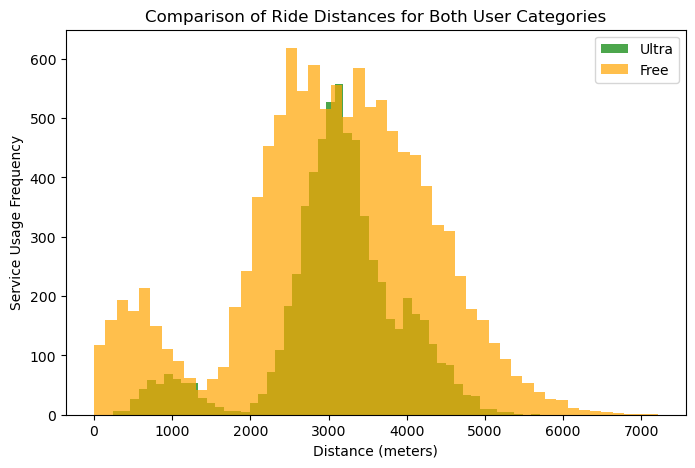

In [40]:
# Plotting histograms to compare distances
plt.figure(figsize=(8, 5))
plt.hist(df_ultra['distance'], alpha=0.7, label='Ultra', color='green', bins=50)
plt.hist(df_free['distance'], alpha=0.7, label='Free', color='orange', bins=50)
plt.title('Comparison of Ride Distances for Both User Categories')
plt.xlabel('Distance (meters)')
plt.ylabel('Service Usage Frequency')
plt.legend();


Both groups exhibit a bimodal distribution of distances. The first peak is around 1000 meters, and the second peak is around 3000–4000 meters. The "Ultra" group shows a higher frequency of rides in the 3000–4000 meter range, whereas the "Free" group displays a more gradual decline after the first peak. The distance distribution for the "Free" group is wider, indicating a greater variety in ride distances among these users.
Users with the "Ultra" subscription tend to use the service for more regular or longer trips (for example, commuting to and from work).


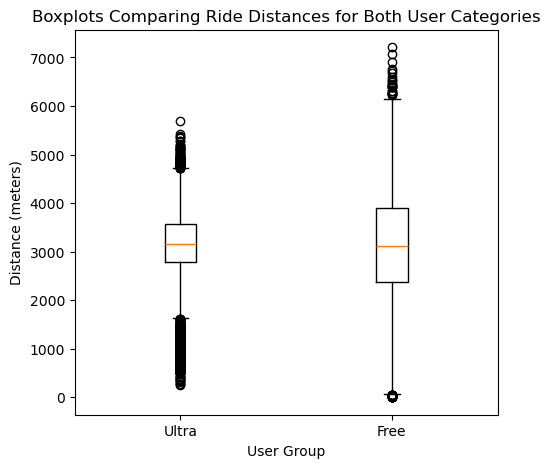

In [41]:
# Box plot for distances
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot([df_ultra['distance'], df_free['distance']], labels=['Ultra', 'Free'])
plt.title('Boxplots Comparing Ride Distances for Both User Categories')
plt.xlabel('User Group')
plt.ylabel('Distance (meters)');


The medians of both groups are approximately at the same level. It is possible that both groups use the service for similar purposes.
The interquartile range and overall spread (from minimum to maximum, including outliers) is larger for the "Free" group than for "Ultra". This indicates greater variability in ride distances among users without a subscription.
The "Free" group has a higher number of outliers at longer distances, which may indicate that some users occasionally take very long or very short rides. The "Ultra" group also has outliers, but fewer.
The upper whisker (which shows the maximum value excluding outliers) is longer for the "Free" group, confirming greater variability in long rides among non-subscribers. The lower whisker starts at roughly the same value for both groups, indicating similarity in minimum distances.


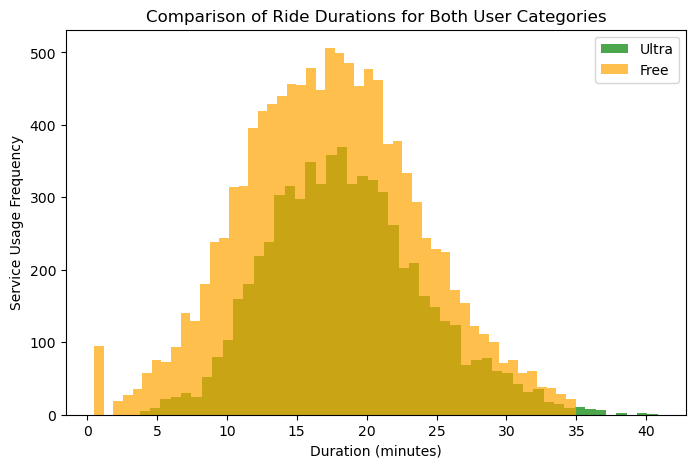

In [42]:
# Plotting histograms to compare ride durations
plt.figure(figsize=(8, 5))
plt.hist(df_ultra['duration'], alpha=0.7, label='Ultra', color='green', bins=50)
plt.hist(df_free['duration'], alpha=0.7, label='Free', color='orange', bins=50)
plt.title('Comparison of Ride Durations for Both User Categories')
plt.xlabel('Duration (minutes)')
plt.ylabel('Service Usage Frequency')
plt.legend();


The majority of rides for both groups last 15–20 minutes.
The peak in ride durations for "Free" users is slightly to the left of that for "Ultra" users. This may indicate that users without a subscription tend to take somewhat shorter rides compared to those with the "Ultra" subscription.
The distribution for both groups is right-skewed, indicating the presence of relatively few rides with very long durations. Such long rides are rare, but they occur in both groups.


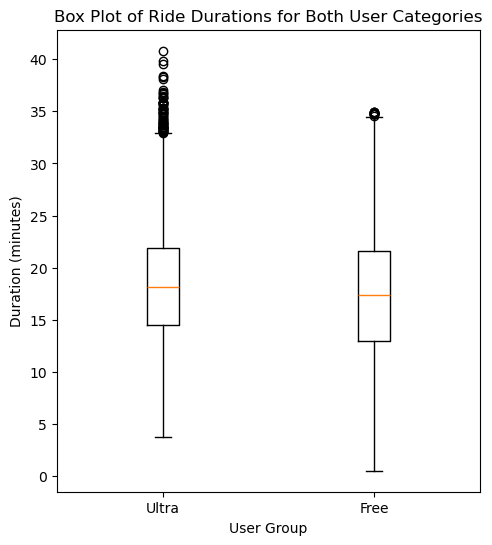

In [43]:
# Box plot for ride durations
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.boxplot([df_ultra['duration'], df_free['duration']], labels=['Ultra', 'Free'])
plt.title('Box Plot of Ride Durations for Both User Categories')
plt.xlabel('User Group')
plt.ylabel('Duration (minutes)');


The distribution of ride durations is similar for both categories, but the "Ultra" group has a few longer rides.
The medians and interquartile ranges are nearly identical.
The upper whisker indicates that, excluding outliers, rides for both groups rarely exceed 30 minutes. The lower whisker starts at approximately 4 minutes for "Ultra" and around 2 minutes for "Free".
The "Ultra" group has rides reaching nearly 40 minutes (outliers), which is higher than for "Free". This may indicate a small number of rides with exceptionally long durations among "Ultra" subscribers.


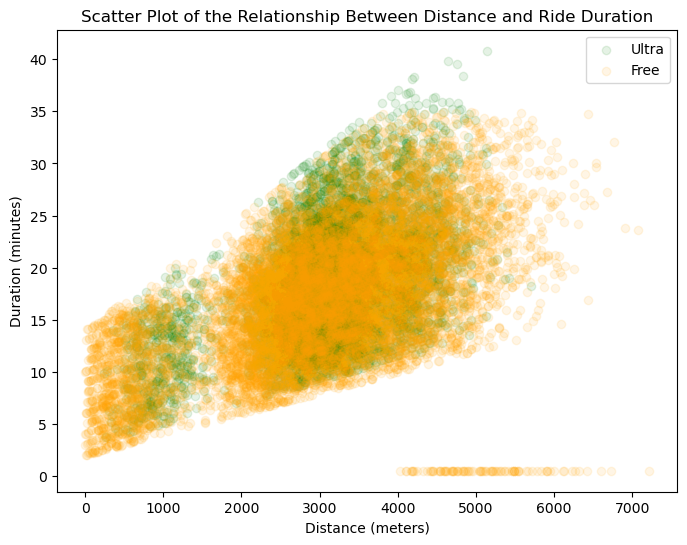

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(df_ultra['distance'], df_ultra['duration'], color='green', label='Ultra', alpha=0.1)
plt.scatter(df_free['distance'], df_free['duration'], color='orange', label='Free', alpha=0.1)
plt.title('Scatter Plot of the Relationship Between Distance and Ride Duration')
plt.xlabel('Distance (meters)')
plt.ylabel('Duration (minutes)')
plt.legend();


The scatter plot shows a clear positive correlation between ride distance and duration for both groups (as distance increases, ride duration increases).  
The highest density of points is concentrated between 0 and 3000 meters and between 5 and 25 minutes.  
Green points (users "Free") cover a wider range and are more densely distributed on the graph, indicating a higher number of rides compared to "Ultra".  
Blue points ("Ultra") show less dispersion, especially at larger distances and durations.


##### Conclusion:
Users with the "Ultra" subscription tend to take more regular and longer rides, whereas "Free" users display more diverse and less predictable ride patterns.

**Distance Comparison:**  
Both groups exhibit a bimodal distribution of ride distances. The first peak is around 1000 meters, and the second is around 3000–4000 meters. "Ultra" users more frequently choose longer rides (3000–4000 m), while "Free" users show greater diversity.  
Based on the box plot: Both groups have similar medians, but the "Free" group shows significantly greater spread and outliers, indicating more varied service usage compared to the more predictable ride patterns of "Ultra" users.

**Ride Duration Comparison:**  
The histogram for ride durations indicates that most rides for both groups last 15–20 minutes, with "Free" users tending to have slightly shorter rides. Both histograms are right-skewed, indicating the presence of occasional long rides. The box plot analysis reveals similar medians and interquartile ranges; however, "Ultra" users have some rides extending up to 40 minutes, reflecting the presence of upper outliers compared to "Free".

The scatter plot confirms the positive correlation between distance and ride duration.


#### Revenue Calculation


We calculate the total distance, the number of rides, and the total ride duration for each user for each month.


In [45]:
# Rounding ride durations using the ceiling function
df_total['duration'] = np.ceil(df_total['duration'])
df_total['distance'] = np.ceil(df_total['distance'])

# Creating a pivot table with ride data
df_pivot = df_total.pivot_table(index=['user_id', 'month_of_publication'], 
                                values=['distance', 'duration', 'name', 'subscription_type'], 
                                aggfunc={'distance': 'sum', 'duration': 'sum', 'name': 'count',
                                         'subscription_type': 'min'})

df_pivot.columns = ['distance_total', 'duration_total', 'ride_count', 'subscription_type']

df_pivot.head(20)


distance_total  duration_total  ride_count  \
user_id month_of_publication                                               
1       1                             7028.0            42.0           2   
        4                              755.0             7.0           1   
        8                             6724.0            46.0           2   
        10                            5811.0            32.0           2   
        11                            7005.0            56.0           3   
        12                            6753.0            28.0           2   
2       3                            10190.0            63.0           3   
        4                             6165.0            40.0           2   
        6                             3256.0            14.0           1   
        7                             6781.0            48.0           2   
        8                              924.0             7.0           1   
        10                            2825.0            19.0           1   
        12                            3829.0            12.0           1   
3       1                             3062.0            13.0           1   
        2                             5422.0            39.0           2   
        4                             2957.0            21.0           1   
        5                             9065.0            63.0           3   
        7                            10921.0            67.0           3   
        9                             2892.0            23.0           1   
        12                            2594.0            13.0           1   

                             subscription_type  
user_id month_of_publication                    
1       1                                ultra  
        4                                ultra  
        8                                ultra  
        10                               ultra  
        11                               ultra  
        12                               ultra  
2       3                                ultra  
        4                                ultra  
        6                                ultra  
        7                                ultra  
        8                                ultra  
        10                               ultra  
        12                               ultra  
3       1                                ultra  
        2                                ultra  
        4                                ultra  
        5                                ultra  
        7                                ultra  
        9                                ultra  
        12                               ultra

In [46]:
# Checking for missing values in the pivot table
print("Missing values in pivot table:\n", df_pivot.isnull().sum())


Missing values in pivot table:
 distance_total       0
duration_total       0
ride_count           0
subscription_type    0
dtype: int64


In [47]:
# Adding a column with the monthly revenue generated by each user

# Calculating monthly revenue for 'ultra' subscribers
df_pivot.loc[df_pivot['subscription_type'] == 'ultra', 'income'] = (df_pivot['duration_total'] * 6) + 199

# Calculating monthly revenue for 'free' users
df_pivot.loc[df_pivot['subscription_type'] == 'free', 'income'] = (df_pivot['ride_count'] * 50) + (df_pivot['duration_total'] * 8)

df_pivot.head(20)


distance_total  duration_total  ride_count  \
user_id month_of_publication                                               
1       1                             7028.0            42.0           2   
        4                              755.0             7.0           1   
        8                             6724.0            46.0           2   
        10                            5811.0            32.0           2   
        11                            7005.0            56.0           3   
        12                            6753.0            28.0           2   
2       3                            10190.0            63.0           3   
        4                             6165.0            40.0           2   
        6                             3256.0            14.0           1   
        7                             6781.0            48.0           2   
        8                              924.0             7.0           1   
        10                            2825.0            19.0           1   
        12                            3829.0            12.0           1   
3       1                             3062.0            13.0           1   
        2                             5422.0            39.0           2   
        4                             2957.0            21.0           1   
        5                             9065.0            63.0           3   
        7                            10921.0            67.0           3   
        9                             2892.0            23.0           1   
        12                            2594.0            13.0           1   

                             subscription_type  income  
user_id month_of_publication                            
1       1                                ultra   451.0  
        4                                ultra   241.0  
        8                                ultra   475.0  
        10                               ultra   391.0  
        11                               ultra   535.0  
        12                               ultra   367.0  
2       3                                ultra   577.0  
        4                                ultra   439.0  
        6                                ultra   283.0  
        7                                ultra   487.0  
        8                                ultra   241.0  
        10                               ultra   313.0  
        12                               ultra   271.0  
3       1                                ultra   277.0  
        2                                ultra   433.0  
        4                                ultra   325.0  
        5                                ultra   577.0  
        7                                ultra   601.0  
        9                                ultra   337.0  
        12                               ultra   277.0

##### Conclusion:
The monthly revenue generated by each user has been calculated, and the corresponding column has been added.


#### Hypothesis Testing


##### Do users with subscriptions spend more time on rides?


This question can be addressed using a hypothesis test comparing the means of two populations.

Null hypothesis: Users with and without subscriptions spend the same amount of time on rides.

Alternative hypothesis: Users with subscriptions spend more time on rides.


In [48]:
# Significance level
alpha = 0.05 

results = st.ttest_ind(df_ultra['duration'], 
                       df_free['duration'], 
                       alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')


p-value: 1.2804098316645618e-34
Reject the null hypothesis


**Conclusion:**  
Users with subscriptions spend more time on rides. This result aligns with earlier histograms comparing ride durations, which indicated fewer very short rides and more long rides among subscribers.


##### Is the average distance per ride for subscribers greater than 3130 meters?


Let's conduct a one-sided hypothesis test in Python.

The optimal distance per ride, considering scooter wear and tear, is 3130 meters.

Null hypothesis: The average distance per ride for subscribers is equal to 3130 meters.

Alternative hypothesis: The average distance per ride for subscribers exceeds 3130 meters.


In [49]:
optimal_distance = 3130

# Significance level
alpha = 0.05

results_2 = st.ttest_1samp(df_ultra['distance'], 
                           optimal_distance, 
                           alternative='greater')

print('p-value:', results_2.pvalue)

if results_2.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis') 


p-value: 0.9195368847849785
Fail to reject the null hypothesis


**Conclusion:**  
We cannot assert that the average distance per ride for subscribers does not exceed 3130 meters.


##### Does monthly revenue from subscribers exceed revenue from non-subscribers?

We will use a hypothesis test comparing the means of two populations.

Null hypothesis: Monthly revenue from subscribers equals revenue from non-subscribers.

Alternative hypothesis: Monthly revenue from subscribers exceeds revenue from non-subscribers.


In [50]:
# Significance level
alpha = 0.05 

income_ultra = df_pivot[df_pivot['subscription_type'] == 'ultra']['income']
income_free = df_pivot[df_pivot['subscription_type'] == 'free']['income']

results = st.ttest_ind(income_ultra, income_free, 
                       alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')


p-value: 1.8850394384715216e-31
Reject the null hypothesis


**Conclusion:**  
Monthly revenue from subscribers exceeds revenue from non-subscribers.


##### Question about test selection  

Situation: The technical team updated servers that interact with the mobile application, hoping this significantly reduces the number of technical support requests. A file contains data on the number of support requests before and after the update for each user. Which test would you use to verify this hypothesis?

Answer: A paired samples t-test (dependent samples t-test) or a hypothesis about the equality of the population means before and after the change.


#### Distributions


#### Final Conclusion


##### Data preprocessing with a description of identified problems and their solutions


The data were provided in the form of three dataframes.

**Data quality:** There were no missing values in the dataframes. Data types matched their content, except for the 'date' column in the df_users dataframe, which originally had the type object. The data type was changed to datetime.

**Duplicates:** In the df_users dataframe, 31 explicit duplicates were found and removed. No explicit duplicates were found in the other dataframes.

A new dataframe combining user data, rides, and subscriptions was created.

**New columns added:**
A column indicating the monthly revenue generated by each user.


##### Exploratory Data Analysis Conclusions


**City Frequency:**  
The highest number of users is in Pyatigorsk (219). High user counts are also found in Yekaterinburg (204), Rostov-on-Don (198), Krasnodar (193), and Sochi (189). Medium user counts occur in Omsk (183) and Tyumen (180). Moscow has the fewest users in this dataset (168).

**Subscription Ratio:**  
835 users without subscriptions (54%), 699 users with subscriptions ("Ultra") (46%).

**User Age:**  
User ages range from 12 to 43 years. The average age is 24.9 years, and the median is 25 years. Most users fall between 22 and 28 years old (first quartile (25%) at 22 years and third quartile (75%) at 28 years).

**Distance per Ride:**  
Average ride distance is 3070.66 meters, with a median of 3133.61 meters. The shortest recorded ride is 0.86 meters, and the longest is 7211.01 meters.  
There are two peaks: a smaller one around 700 meters (short urban rides) and a larger one around 3200 meters.

**Ride Duration:**  
Average ride duration is 17.81 minutes, with a median of 17.68 minutes. The shortest ride is 0.5 minutes, and the longest ride is 40.82 minutes. 25% of rides last less than 13.60 minutes, and 75% last less than 21.72 minutes.

**Comparing Distance and Duration for Both User Categories:**  
"Ultra" subscribers tend to take more regular and longer rides, whereas "Free" users show more diverse and less predictable riding patterns.

**Distance Comparison:**  
"Ultra" users often choose longer rides (3000-4000 meters), whereas "Free" users exhibit greater variety.  
Box plots indicate similar medians for both groups, but "Free" users have significantly more variation and outliers, suggesting more diverse usage patterns compared to "Ultra" users' predictable patterns.

**Ride Duration Comparison:**  
Most rides for both groups last between 15-20 minutes. "Free" users tend to take slightly shorter rides, while "Ultra" users have noticeably longer rides, reaching up to 40 minutes, indicating more upper-end outliers compared to "Free".


##### Conclusions from Hypothesis Testing


**Do subscribers spend more time on rides?**  
Yes, subscribers spend more time on rides.

**Does the average distance per ride for subscribers exceed 3130 meters?**  
We cannot confirm this (the null hypothesis is not rejected).

**Does monthly revenue from subscribers exceed revenue from non-subscribers?**  
Yes, it does.


##### Recommendations for the Client:

**Improving the Subscription Program:**  
Since subscribers generate more revenue, consider refining subscription terms, introducing additional benefits, or discounts for longer rides. Special offers could encourage "Free" users to upgrade to subscriptions.

**Promoting Longer Rides:**  
For "Ultra" subscribers who prefer longer rides, offer special conditions for frequent or regular trips to enhance customer loyalty.

**Reviewing Pricing Structures:**  
Analyze and optimize the pricing structure, potentially introducing different rates for specific times of day or days of the week.

**Enhancing User Experience:**  
Introduce new features such as:
- Route suggestions based on analysis of popular destinations.
- Personalized recommendations for optimizing ride expenses.
- Improved navigation and trip-planning capabilities.
